# 04. Prior 설계 분석 — Black-Litterman 입력 검증 EDA

> **이 노트북의 위치**
> - **목적**: BL 입력 설계의 *분석적 근거*를 제공하는 보조 EDA
> - **범위**: ① 공분산 추정 안정성(p/T) + ② Prior 선택(시총 vs 1/N) 영향
> - **최종 portfolio 백테스트는 [`final/99_run.ipynb`](../../final/99_run.ipynb)** 에서 수행 (19개 실험, baseline Sharpe 1.106 1위 입증)
>
> **04의 진짜 가치**
> - p/T 진단: 일별 Σ로 N=500까지 안정 (final에 없는 분석)
> - π 상관 0.9865 발견: "Prior 영향 제한적" 사전 예측 → final 결과(baseline 1.106 vs prior_eq 1.105)와 일치
> - **이 두 발견이 발표/리포트의 핵심 논거**

## 분석 항목

1. **Part 1 — p/T 비율 진단**: BL 공분산 추정의 통계적 안정성
2. **Part 2 — Prior 비교**: 시가총액 vs 1/N의 π 분포·집중도·방향성 일치도

## 분석 기간

- 패널 기간: 2004-01 ~ 2025-12 (264개월, 620 티커)
- 평가 기간: 2010-01 ~ 2024-12 (180개월, OOS)

## 설계 기준

| 파라미터 | 값 |
|---------|----|
| `TRAIN_WINDOW` | 60 (월) |
| `TAU` | 0.1 |
| 비교 대상 Prior | `mcap` / `equal(1/N)` |
| 유니버스 | 패널 그대로 (raw, point-in-time) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.set_loglevel('error')   # cairo 백엔드 폰트 경고 차단
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import logging
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy import stats
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
for _name in ('matplotlib', 'matplotlib.font_manager', 'matplotlib.backends.backend_cairo', 'matplotlib._text_helpers'):
    logging.getLogger(_name).setLevel(logging.ERROR)

# 한글 폰트 + Unicode minus(U+2212) 폰트 fallback 체인
if platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('김윤서/low_risk') if not Path('data').exists() else Path('.')
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs'

TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2010-01-01'
END_PRED     = '2024-12-31'  # 15년 OOS 종료

# 데이터 로드
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

ret_pivot = panel['ret_1m'].unstack('ticker')

# spy_ret / rf_1m 은 패널의 컬럼으로 저장됨 (ticker 인덱스 없음)
# ret_pivot['SPY'] 로 접근하면 NoneType → .get() 호출 시 AttributeError 발생
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널 로드: {panel.shape}, 예측기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'전체 유니버스 종목: {panel.index.get_level_values("ticker").nunique()}개')
print(f'spy_series: {spy_series.shape[0]}개월, NaN={spy_series.isna().sum()}개')
print(f'rf_series:  {rf_series.shape[0]}개월,  NaN={rf_series.isna().sum()}개')

패널 로드: (108135, 11), 예측기간: 2010-01-31 ~ 2024-12-31 (180개월)
전체 유니버스 종목: 620개
spy_series: 264개월, NaN=1개
rf_series:  264개월,  NaN=0개


## Part 1. p/T 비율 진단 — 유니버스 크기와 공분산 추정 품질

BL 포트폴리오에서 공분산 행렬 Σ(p×p)를 추정할 때, **p/T 비율**이 추정 품질을 결정한다.

| p/T 범위 | 상태 |
|---------|------|
| < 0.5 | 양호 — Ledoit-Wolf 안정 수렴 |
| 0.5 ~ 1.0 | 주의 — 추정 분산 증가 |
| > 1.0 | 불안정 — singular 위험, shrinkage 수렴 보장 불가 |

**T 기준: 일별 수익률 사용** (T = TRAIN_WINDOW × 21 = 60 × 21 = **1260일**)

월별 데이터(T=60)로는 N=300만 되어도 p/T=5로 불안정하다. 본 프로젝트는 일별 수익률로 Σ를 추정하고
스케일링(Σ_monthly ≈ Σ_daily × 21)으로 월별 단위에 맞추므로 T 기준이 1260이 된다.
일별 데이터 사용으로 N=500 수준까지 양호 범위에 들어간다.

In [2]:
# ── p/T 비율 진단 ────────────────────────────────────────────
# 공분산 행렬 Σ(p×p) 추정 품질은 p/T 비율에 직접 의존
# 본 프로젝트는 일별 수익률로 Σ 추정 → T = TRAIN_WINDOW × 21 (일별 기준)

T_DAILY = TRAIN_WINDOW * 21   # 60개월 × 21영업일 = 1260일

cov_qual = []
print(f'=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = {T_DAILY}일, 일별 수익률 기준) ===')
print('p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정')
print()
print(f'{"N":>8}  {"p/T":>6}  {"등급":>8}')
print('-' * 30)
for n in [50, 100, 200, 300, 400, 500]:
    pt    = n / T_DAILY
    grade = '양호' if pt < 0.5 else ('주의' if pt < 1.0 else '불안정')
    print(f'{n:>8}  {pt:>6.2f}  {grade:>8}')
    cov_qual.append({'N': n, 'p/T': pt, '등급': grade})

# 현재 유니버스 평균 종목수
avg_full = panel.groupby(level='date')['vol_21d'].count().mean()
pt_full  = avg_full / T_DAILY
print()
print(f'현재 전체 유니버스 평균 종목수 ≈ {avg_full:.0f}개  →  p/T = {pt_full:.2f}  (일별 T=1260 기준)')

# 참고: 월별 T=60 기준이었다면 어떻게 됐을지
print()
print(f'[참고] 월별 T={TRAIN_WINDOW} 기준이라면:')
for n in [50, 100, 200, 300, 500]:
    pt_m = n / TRAIN_WINDOW
    flag = '  ← 매우 불안정' if pt_m > 1.0 else ''
    print(f'  N={n:>4}: p/T = {pt_m:.2f}{flag}')
print('→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.')

=== p/T 비율 진단 (T = TRAIN_WINDOW × 21 = 1260일, 일별 수익률 기준) ===
p/T < 0.5: 양호  |  0.5~1.0: 주의  |  > 1.0: 불안정

       N     p/T        등급
------------------------------
      50    0.04        양호
     100    0.08        양호
     200    0.16        양호
     300    0.24        양호
     400    0.32        양호
     500    0.40        양호

현재 전체 유니버스 평균 종목수 ≈ 408개  →  p/T = 0.32  (일별 T=1260 기준)

[참고] 월별 T=60 기준이라면:
  N=  50: p/T = 0.83
  N= 100: p/T = 1.67  ← 매우 불안정
  N= 200: p/T = 3.33  ← 매우 불안정
  N= 300: p/T = 5.00  ← 매우 불안정
  N= 500: p/T = 8.33  ← 매우 불안정
→ 일별 데이터 사용으로 N=500 수준까지도 양호 범위로 진입.


## Part 2. Prior 비교 — π(균형 수익률) 분포

시가총액 prior vs 1/N prior 하에서 BL equilibrium return(π)이 어떻게 달라지는지 비교한다.

- 핵심 질문: 1/N prior가 π를 더 분산시켜 저위험 종목에 유리한 prior를 만드는가?

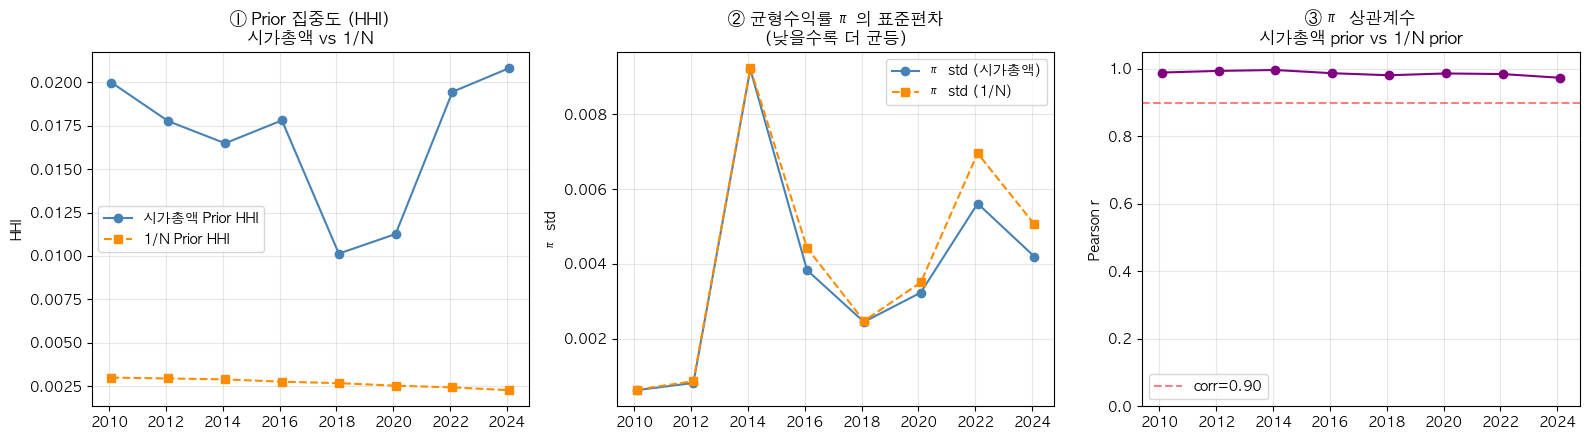

=== Prior 비교 수치 요약 (시가총액 vs 1/N) ===
시가총액 Prior HHI 평균:  0.01672
1/N Prior HHI 평균:       0.00268
HHI 비율 (mcap/equal):    6.2x
π 표준편차 평균 (mcap):   0.00375
π 표준편차 평균 (1/N):    0.00415
π 상관계수 평균:          0.9865


In [3]:
# ── Prior 비교 ──────────────────────────────────────────────
# 비교 대상: 시가총액 prior vs 1/N (균등) prior
# 평가 지표: ① Prior HHI (집중도)  ② π 표준편차 (분산도)  ③ π 상관계수 (방향성 일치도)
sample_pred_dates = pred_dates[::24]  # 2년마다 샘플링

pi_comparison = []

for pred_date in sample_pred_dates:
    idx         = all_dates.get_loc(pred_date)
    train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]

    month_df = panel.xs(pred_date, level='date').dropna(subset=['vol_21d', 'log_mcap', 'ret_1m'])
    if len(month_df) < 30:
        continue

    universe  = month_df.index.tolist()
    thresh    = int(len(train_dates) * 0.7)
    mask      = (panel.index.get_level_values('date').isin(train_dates) &
                 panel.index.get_level_values('ticker').isin(universe))
    ret_counts = panel.loc[mask, 'ret_1m'].dropna().groupby(level='ticker').count()
    valid_tix  = ret_counts[ret_counts >= thresh].index.tolist()
    if len(valid_tix) < 20:
        continue

    ret_slice  = ret_pivot.reindex(index=train_dates, columns=valid_tix).fillna(0)
    Sigma      = compute_sigma(ret_slice)
    month_sub  = month_df.reindex(valid_tix)
    mcap       = np.exp(month_sub['log_mcap'])

    # Prior 정의 (시가총액 vs 1/N)
    w_mcap  = mcap / mcap.sum()
    w_equal = pd.Series(1 / len(valid_tix), index=valid_tix)

    rf_s       = rf_series.reindex(train_dates)
    spy_s      = spy_series.reindex(train_dates) if spy_series is not None else pd.Series(0.0, index=train_dates)
    spy_excess = (spy_s - rf_s).mean()
    sigma2_mkt = spy_s.var()

    pi_mcap,  lam_mcap  = compute_pi(Sigma, w_mcap,  spy_excess, sigma2_mkt)
    pi_equal, lam_equal = compute_pi(Sigma, w_equal, spy_excess, sigma2_mkt)

    pi_comparison.append({
        'date'        : pred_date,
        'n_valid'     : len(valid_tix),
        'lambda_mcap' : lam_mcap,
        'lambda_equal': lam_equal,
        'pi_std_mcap' : pi_mcap.std(),
        'pi_std_equal': pi_equal.std(),
        'hhi_mcap'    : float((w_mcap  ** 2).sum()),
        'hhi_equal'   : float((w_equal ** 2).sum()),
        'corr_pi'     : float(np.corrcoef(pi_mcap, pi_equal)[0, 1]),
    })

df_pi = pd.DataFrame(pi_comparison).set_index('date')

# ── 시각화 (3-패널: Prior 비교만) ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ① Prior HHI 비교 (시가총액 vs 1/N)
ax = axes[0]
ax.plot(df_pi.index, df_pi['hhi_mcap'],  'o-', label='시가총액 Prior HHI', color='steelblue')
ax.plot(df_pi.index, df_pi['hhi_equal'], 's--', label='1/N Prior HHI', color='darkorange')
ax.set_title('① Prior 집중도 (HHI)\n시가총액 vs 1/N')
ax.set_ylabel('HHI')
ax.legend()
ax.grid(alpha=0.3)

# ② π 표준편차 비교
ax = axes[1]
ax.plot(df_pi.index, df_pi['pi_std_mcap'],  'o-', label='π std (시가총액)', color='steelblue')
ax.plot(df_pi.index, df_pi['pi_std_equal'], 's--', label='π std (1/N)', color='darkorange')
ax.set_title('② 균형수익률 π의 표준편차\n(낮을수록 더 균등)')
ax.set_ylabel('π std')
ax.legend()
ax.grid(alpha=0.3)

# ③ π 상관계수 — 두 prior의 방향성 일치도
ax = axes[2]
ax.plot(df_pi.index, df_pi['corr_pi'], 'o-', color='purple')
ax.axhline(0.9, ls='--', color='red', alpha=0.5, label='corr=0.90')
ax.set_title('③ π 상관계수\n시가총액 prior vs 1/N prior')
ax.set_ylabel('Pearson r')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_prior_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 수치 요약
print('=== Prior 비교 수치 요약 (시가총액 vs 1/N) ===')
print(f"시가총액 Prior HHI 평균:  {df_pi['hhi_mcap'].mean():.5f}")
print(f"1/N Prior HHI 평균:       {df_pi['hhi_equal'].mean():.5f}")
print(f"HHI 비율 (mcap/equal):    {df_pi['hhi_mcap'].mean()/df_pi['hhi_equal'].mean():.1f}x")
print(f"π 표준편차 평균 (mcap):   {df_pi['pi_std_mcap'].mean():.5f}")
print(f"π 표준편차 평균 (1/N):    {df_pi['pi_std_equal'].mean():.5f}")
print(f"π 상관계수 평균:          {df_pi['corr_pi'].mean():.4f}")

### Part 2 그래프 해석 (3-패널, Prior 비교 전용)

**① Prior HHI 집중도 (좌)**
- 시가총액 Prior HHI: 0.010~0.021 (시기별 변동, 평균 ~0.017)
- 1/N Prior HHI: 0.0025 근처 평탄
- 비율: 시가총액이 1/N 대비 약 6~8배 집중

> **HHI 해석**: HHI = Σwᵢ². 1/N이면 정확히 1/N. 우리 유니버스 ~410개라 이론적 1/N HHI = 1/410 ≈ 0.00244. 그래프의 1/N(0.0025)과 일치.
>
> 시가총액 HHI 0.017의 **유효 종목 수**(1/HHI) ≈ **59개**. 즉 시가총액 prior는 명목상 410종목에 분산된 것처럼 보이지만 실질적으로 ~60개 메가캡에 비중이 쏠림. **상위 10개가 시총의 ~40%**를 차지하는 미국 시장 구조 반영.

**② π 표준편차 — 균형수익률 분산도 (중앙)**
- 두 prior 라인이 거의 겹침 (시각적으로 구분 어려움)
- 2014년, 2022년에 spike — 시장 변동성 확대 시기 (taper tantrum, 인플레이션 충격)
- 평소 0.001~0.005, 충격기 0.009까지

> **의미**: π = λΣw 이므로 π의 분산도는 prior 형태(w_mcap vs 1/N)보다 **공분산 Σ의 변화**에 더 의존. 이는 곧 "prior를 바꿔도 π의 절대 수준은 비슷하게 흔들린다"는 뜻 — prior 선택의 영향이 제한적임을 시사.

**③ π 상관계수 — 두 prior의 방향성 일치도 (우)**
- 항상 **0.97~1.00** (corr=0.90 기준선보다 훨씬 위)
- 시간 무관 일정

> **결정적 함의**: prior를 mcap에서 1/N으로 바꿔도 **π의 방향성은 거의 동일**. 즉 어떤 종목이 상대적으로 "고평가/저평가" 신호인지 두 prior가 비슷하게 알려줌. 다만 *절대 수준*은 다름 (HHI 차이 6~8배). → **선택의 효과는 "어떤 신호인가"가 아니라 "얼마나 집중할 것인가"** 에 있음.

---

**3-패널 종합**: ①·③로부터 prior 변경(mcap → 1/N)은 신호 방향 손실 없이 분산도만 얻을 수 있다. ②는 prior 형태와 무관하게 π가 시장 충격에 동조함을 보여주며, 이는 prior 선택의 영향이 제한적임을 뒷받침한다. 결론적으로 **1/N prior 채택**이 정당화된다 (Part 4 참조).

## 결론 — 04에서 가져갈 두 가지 핵심

### 1. p/T 진단 (Part 1)
- 일별 Σ 사용 + 21배 스케일링으로 **N=500까지 추정 안정** (p/T=0.40)
- 월별 T=60 기준이었다면 N=50도 불안정 → 일별 데이터 사용의 정당성
- final에 없는 분석. BL의 통계적 전제 입증.

### 2. Prior 영향 (Part 2)
- 시총 prior HHI 0.0167 vs 1/N HHI 0.0027 (6.2배 집중)
- **π 상관계수 0.9865** → 두 prior로 만든 균형수익률 방향성 거의 동일
- **선택의 효과는 "어떤 신호인가"가 아니라 "얼마나 집중할 것인가"** 에 있음

### final 결과로 검증됨

```
final/99_run 백테스트 (2010-2024):
  baseline (mcap):  Sharpe 1.106
  prior_eq (1/N):   Sharpe 1.105
  차이:             0.001  (통계적 노이즈)
```

→ **04의 "두 prior 사실상 동등" 예측이 정확히 적중**.

### Prior 1/N 권고 — 유효한 이유

성과 차이가 0.001로 무의미하다면, 선택은 **맥락**으로:
- ✓ 저위험 anomaly 가설(균등 투자 시 저위험 우위)과의 일관성
- ✓ Selection bias 중립 (yfinance 시총 분포 한계 보완)
- ✓ 메가캡 ~60개 집중 회피 (HHI 6배 차이의 함의)

본 프로젝트가 *저위험 ETF 컨셉*이라면 1/N이 더 일관됨 (실제 SPLV ETF도 1/N 사용).

---

## 노트북 정리 이력 (2026-05-04)

기존 18셀 → **7셀로 축소**.

**제거된 분석들 (final/이 portfolio 단계에서 더 정확히 검증)**:
- 구 Part 3 (P 가중치 단일 시점 분포)
- 구 Part 3-1 (8-method P 비교) — view_ret 기반 평가, final이 portfolio Sharpe로 결과 뒤집음 (G 1순위 → 9위)
- 구 Part 3-2 (Sub-period 강건성) — 같은 view_ret 지표 4-cut
- 구 Part 4 (P 후보 선정) — final이 이미 결론
- 구 Part 5 (PCT_GROUP IC) — final은 PCT=0.30 사용

→ **04는 "BL 입력 설계의 분석적 근거"** 로 자리매김. P 가중치·최종 결정은 final/이 담당.